# Ejemplo de circuito 1
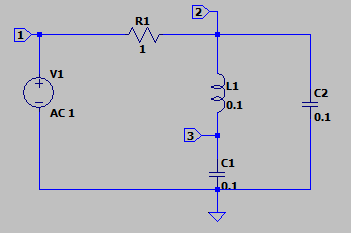

In [115]:
import os
from sympy import *
import numpy as np
from scipy import signal
import matplotlib.pyplot as plt
import pandas as pd
from tabulate import tabulate
from IPython.display import display, Markdown, Math, Latex
init_printing()

In [116]:
# initialize variables
num_rlc = 0 # number of passive elements
num_ind = 0 # number of inductors
num_v = 0    # number of independent voltage sources
num_i = 0    # number of independent current sources
i_unk = 0  # number of current unknowns
num_opamps = 0   # number of op amps
num_vcvs = 0     # number of controlled sources of various types
num_vccs = 0
num_cccs = 0
num_ccvs = 0
num_cpld_ind = 0 # number of coupled inductors

leemos el netlist

In [117]:
net_list = '''
R1 2 1 1
V1 1 0 1
L1 2 3 0.1 Rser=0
C1 3 0 0.1
C2 2 0 0.1
'''

Filtramos el netlist para evitar errores

In [118]:
content = net_list.splitlines()

content = [x.strip() for x in content]  #remove leading and trailing white space
# remove empty lines
while '' in content:
    content.pop(content.index(''))

# remove comment lines, these start with a asterisk *
content = [n for n in content if not n.startswith('*')]
# remove other comment lines, these start with a semicolon ;
content = [n for n in content if not n.startswith(';')]
# remove SPICE directives, these start with a period, .
content = [n for n in content if not n.startswith('.')]
# converts 1st letter to upper case
#content = [x.upper() for x in content] <- this converts all to upper case
content = [x.capitalize() for x in content]
# removes extra spaces between entries
content = [' '.join(x.split()) for x in content]

In [119]:
# display the cleaned up netlist
for i in content:
    print(i)

R1 2 1 1
V1 1 0 1
L1 2 3 0.1 rser=0
C1 3 0 0.1
C2 2 0 0.1


In [120]:
line_cnt = len(content) # number of lines in the netlist
branch_cnt = 0  # number of branches in the netlist
# check number of entries on each line, count each element type
for i in range(line_cnt):
    x = content[i][0]
    tk_cnt = len(content[i].split()) # split the line into a list of words

    if (x == 'R') or (x == 'L') or (x == 'C'):
        if tk_cnt != 4:
            print("branch {:d} not formatted correctly, {:s}".format(i,content[i]))
            print("had {:d} items and should only be 4".format(tk_cnt))
        num_rlc += 1
        branch_cnt += 1
        if x == 'L':
            num_ind += 1
    elif x == 'V':
        if tk_cnt != 4:
            print("branch {:d} not formatted correctly, {:s}".format(i,content[i]))
            print("had {:d} items and should only be 4".format(tk_cnt))
        num_v += 1
        branch_cnt += 1
    elif x == 'I':
        if tk_cnt != 4:
            print("branch {:d} not formatted correctly, {:s}".format(i,content[i]))
            print("had {:d} items and should only be 4".format(tk_cnt))
        num_i += 1
        branch_cnt += 1
    elif x == 'O':
        if tk_cnt != 4:
            print("branch {:d} not formatted correctly, {:s}".format(i,content[i]))
            print("had {:d} items and should only be 4".format(tk_cnt))
        num_opamps += 1
    elif x == 'E':
        if (tk_cnt != 6):
            print("branch {:d} not formatted correctly, {:s}".format(i,content[i]))
            print("had {:d} items and should only be 6".format(tk_cnt))
        num_vcvs += 1
        branch_cnt += 1
    elif x == 'G':
        if (tk_cnt != 6):
            print("branch {:d} not formatted correctly, {:s}".format(i,content[i]))
            print("had {:d} items and should only be 6".format(tk_cnt))
        num_vccs += 1
        branch_cnt += 1
    elif x == 'F':
        if (tk_cnt != 5):
            print("branch {:d} not formatted correctly, {:s}".format(i,content[i]))
            print("had {:d} items and should only be 5".format(tk_cnt))
        num_cccs += 1
        branch_cnt += 1
    elif x == 'H':
        if (tk_cnt != 5):
            print("branch {:d} not formatted correctly, {:s}".format(i,content[i]))
            print("had {:d} items and should only be 5".format(tk_cnt))
        num_ccvs += 1
        branch_cnt += 1
    elif x == 'K':
        if (tk_cnt != 4):
            print("branch {:d} not formatted correctly, {:s}".format(i,content[i]))
            print("had {:d} items and should only be 4".format(tk_cnt))
        num_cpld_ind += 1
    else:
        print("unknown element type in branch {:d}, {:s}".format(i,content[i]))

branch 2 not formatted correctly, L1 2 3 0.1 rser=0
had 5 items and should only be 4


In [121]:
# build the pandas data frame
df = pd.DataFrame(columns=['element','p node','n node','cp node','cn node',
    'Vout','value','Vname','Lname1','Lname2'])

# this data frame is for branches with unknown currents
df2 = pd.DataFrame(columns=['element','p node','n node'])

In [122]:
# loads voltage or current sources into branch structure
def indep_source(line_nu):
    tk = content[line_nu].split()
    df.loc[line_nu,'element'] = tk[0]
    df.loc[line_nu,'p node'] = int(tk[1])
    df.loc[line_nu,'n node'] = int(tk[2])
    df.loc[line_nu,'value'] = float(tk[3])

# loads passive elements into branch structure
def rlc_element(line_nu):
    tk = content[line_nu].split()
    df.loc[line_nu,'element'] = tk[0]
    df.loc[line_nu,'p node'] = int(tk[1])
    df.loc[line_nu,'n node'] = int(tk[2])
    df.loc[line_nu,'value'] = float(tk[3])

# loads multi-terminal elements into branch structure
# O - Op Amps
def opamp_sub_network(line_nu):
    tk = content[line_nu].split()
    df.loc[line_nu,'element'] = tk[0]
    df.loc[line_nu,'p node'] = int(tk[1])
    df.loc[line_nu,'n node'] = int(tk[2])
    df.loc[line_nu,'Vout'] = int(tk[3])

# G - VCCS
def vccs_sub_network(line_nu):
    tk = content[line_nu].split()
    df.loc[line_nu,'element'] = tk[0]
    df.loc[line_nu,'p node'] = int(tk[1])
    df.loc[line_nu,'n node'] = int(tk[2])
    df.loc[line_nu,'cp node'] = int(tk[3])
    df.loc[line_nu,'cn node'] = int(tk[4])
    df.loc[line_nu,'value'] = float(tk[5])

# E - VCVS
# in SymPy E is the number 2.718, replacing E with Ea otherwise, sympify() errors out
def vcvs_sub_network(line_nu):
    tk = content[line_nu].split()
    df.loc[line_nu,'element'] = tk[0].replace('E', 'Ea')
    df.loc[line_nu,'p node'] = int(tk[1])
    df.loc[line_nu,'n node'] = int(tk[2])
    df.loc[line_nu,'cp node'] = int(tk[3])
    df.loc[line_nu,'cn node'] = int(tk[4])
    df.loc[line_nu,'value'] = float(tk[5])

# F - CCCS
def cccs_sub_network(line_nu):
    tk = content[line_nu].split()
    df.loc[line_nu,'element'] = tk[0]
    df.loc[line_nu,'p node'] = int(tk[1])
    df.loc[line_nu,'n node'] = int(tk[2])
    df.loc[line_nu,'Vname'] = tk[3].capitalize()
    df.loc[line_nu,'value'] = float(tk[4])

# H - CCVS
def ccvs_sub_network(line_nu):
    tk = content[line_nu].split()
    df.loc[line_nu,'element'] = tk[0]
    df.loc[line_nu,'p node'] = int(tk[1])
    df.loc[line_nu,'n node'] = int(tk[2])
    df.loc[line_nu,'Vname'] = tk[3].capitalize()
    df.loc[line_nu,'value'] = float(tk[4])

# K - Coupled inductors
def cpld_ind_sub_network(line_nu):
    tk = content[line_nu].split()
    df.loc[line_nu,'element'] = tk[0]
    df.loc[line_nu,'Lname1'] = tk[1].capitalize()
    df.loc[line_nu,'Lname2'] = tk[2].capitalize()
    df.loc[line_nu,'value'] = float(tk[3])

# function to scan df and get largest node number
def count_nodes():
    # need to check that nodes are consecutive
    # fill array with node numbers
    p = np.zeros(line_cnt+1)
    for i in range(line_cnt):
        # need to skip coupled inductor 'K' statements
        if df.loc[i,'element'][0] != 'K': #get 1st letter of element name
            p[df['p node'][i]] = df['p node'][i]
            p[df['n node'][i]] = df['n node'][i]

    # find the largest node number
    if df['n node'].max() > df['p node'].max():
        largest = df['n node'].max()
    else:
        largest =  df['p node'].max()

    largest = int(largest)
    # check for unfilled elements, skip node 0
    for i in range(1,largest):
        if p[i] == 0:
            print('nodes not in continuous order, node {:.0f} is missing'.format(p[i-1]+1))

    return largest

In [123]:
# load branch info into data frame
for i in range(line_cnt):
    x = content[i][0]

    if (x == 'R') or (x == 'L') or (x == 'C'):
        rlc_element(i)
    elif (x == 'V') or (x == 'I'):
        indep_source(i)
    elif x == 'O':
        opamp_sub_network(i)
    elif x == 'E':
        vcvs_sub_network(i)
    elif x == 'G':
        vccs_sub_network(i)
    elif x == 'F':
        cccs_sub_network(i)
    elif x == 'H':
        ccvs_sub_network(i)
    elif x == 'K':
        cpld_ind_sub_network(i)
    else:
        print("unknown element type in branch {:d}, {:s}".format(i,content[i]))

In [124]:
# Check for the position of voltage sources in the data frame.
source_index = [] # keep track of voltage source row number
other_index = [] # make a list of all other types
for i in range(len(df)):
    # process all the elements creating unknown currents
    x = df.loc[i,'element'][0]   #get 1st letter of element name
    if (x == 'V'):
        source_index.append(i)
    else:
        other_index.append(i)

df = df.reindex(source_index+other_index,copy=True) # reorder the data frame
df.reset_index(drop=True, inplace=True) # renumber the index

C:\Users\mrodr\AppData\Local\Temp\ipykernel_28716\3467464880.py:12: Pandas4Warning: The copy keyword is deprecated and will be removed in a future version. Copy-on-Write is active in pandas since 3.0 which utilizes a lazy copy mechanism that defers copies until necessary. Use .copy() to make an eager copy if necessary.
  df = df.reindex(source_index+other_index,copy=True) # reorder the data frame


In [125]:
# count number of nodes
num_nodes = count_nodes()

# Build df2: consists of branches with current unknowns, used for C & D matrices
# walk through data frame and find these parameters
count = 0
for i in range(len(df)):
    # process all the elements creating unknown currents
    x = df.loc[i,'element'][0]   #get 1st letter of element name
    if (x == 'L') or (x == 'V') or (x == 'O') or (x == 'E') or (x == 'H') or (x == 'F'):
        df2.loc[count,'element'] = df.loc[i,'element']
        df2.loc[count,'p node'] = df.loc[i,'p node']
        df2.loc[count,'n node'] = df.loc[i,'n node']
        count += 1

In [126]:
# print a report
print('Netlist report')
print('number of lines in netlist: {:d}'.format(line_cnt))
print('number of branches: {:d}'.format(branch_cnt))
print('number of nodes: {:d}'.format(num_nodes))
# count the number of element types that affect the size of the B, C, D, E and J arrays
# these are current unknows
i_unk = num_v+num_opamps+num_vcvs+num_ccvs+num_cccs+num_ind
print('number of unknown currents: {:d}'.format(i_unk))
print('number of RLC (passive components): {:d}'.format(num_rlc))
print('number of inductors: {:d}'.format(num_ind))
print('number of independent voltage sources: {:d}'.format(num_v))
print('number of independent current sources: {:d}'.format(num_i))
print('number of op amps: {:d}'.format(num_opamps))
print('number of E - VCVS: {:d}'.format(num_vcvs))
print('number of G - VCCS: {:d}'.format(num_vccs))
print('number of F - CCCS: {:d}'.format(num_cccs))
print('number of H - CCVS: {:d}'.format(num_ccvs))
print('number of K - Coupled inductors: {:d}'.format(num_cpld_ind))

Netlist report
number of lines in netlist: 5
number of branches: 5
number of nodes: 3
number of unknown currents: 2
number of RLC (passive components): 4
number of inductors: 1
number of independent voltage sources: 1
number of independent current sources: 0
number of op amps: 0
number of E - VCVS: 0
number of G - VCCS: 0
number of F - CCCS: 0
number of H - CCVS: 0
number of K - Coupled inductors: 0


In [127]:
df

,element,p node,n node,cp node,cn node,Vout,value,Vname,Lname1,Lname2
0,V1,1,0,NaN,NaN,NaN,1.0,NaN,NaN,NaN
1,R1,2,1,NaN,NaN,NaN,1.0,NaN,NaN,NaN
2,L1,2,3,NaN,NaN,NaN,0.1,NaN,NaN,NaN
3,C1,3,0,NaN,NaN,NaN,0.1,NaN,NaN,NaN
4,C2,2,0,NaN,NaN,NaN,0.1,NaN,NaN,NaN


In [128]:
df2

,element,p node,n node
0,V1,1,0
1,L1,2,3


In [129]:
V = zeros(num_nodes,1)
I = zeros(num_nodes,1)
G = zeros(num_nodes,num_nodes)  # also called Yr, the reduced nodal matrix
s = Symbol('s')  # the Laplace variable

# count the number of element types that affect the size of the B, C, D, E and J arrays
# these are element types that have unknown currents
i_unk = num_v+num_opamps+num_vcvs+num_ccvs+num_ind+num_cccs
# if i_unk == 0, just generate empty arrays
B = zeros(num_nodes,i_unk)
C = zeros(i_unk,num_nodes)
D = zeros(i_unk,i_unk)
Ev = zeros(i_unk,1)
J = zeros(i_unk,1)

In [130]:
# G matrix
for i in range(len(df)):  # process each row in the data frame
    n1 = df.loc[i,'p node']
    n2 = df.loc[i,'n node']
    cn1 = df.loc[i,'cp node']
    cn2 = df.loc[i,'cn node']
    # process all the passive elements, save conductance to temp value
    x = df.loc[i,'element'][0]   # get 1st letter of element name
    if x == 'R':
        g = 1/sympify(df.loc[i,'element'])
    if x == 'C':
        g = s*sympify(df.loc[i,'element'])
    if x == 'G':   #vccs type element
        g = sympify(df.loc[i,'element'].lower())  # use a symbol for gain value

    if (x == 'R') or (x == 'C'):
        # If neither side of the element is connected to ground
        # then subtract it from the appropriate location in the matrix.
        if (n1 != 0) and (n2 != 0):
            G[n1-1,n2-1] += -g
            G[n2-1,n1-1] += -g

        # If node 1 is connected to ground, add element to diagonal of matrix
        if n1 != 0:
            G[n1-1,n1-1] += g

        # same for for node 2
        if n2 != 0:
            G[n2-1,n2-1] += g

    if x == 'G':    #vccs type element
        # check to see if any terminal is grounded
        # then stamp the matrix
        if n1 != 0 and cn1 != 0:
            G[n1-1,cn1-1] += g

        if n2 != 0 and cn2 != 0:
            G[n2-1,cn2-1] += g

        if n1 != 0 and cn2 != 0:
            G[n1-1,cn2-1] -= g

        if n2 != 0 and cn1 != 0:
            G[n2-1,cn1-1] -= g

G  # display the G matrix

⎡1       -1          ⎤
⎢──      ───      0  ⎥
⎢R₁      R₁          ⎥
⎢                    ⎥
⎢-1          1       ⎥
⎢───  C₂⋅s + ──   0  ⎥
⎢R₁          R₁      ⎥
⎢                    ⎥
⎣ 0       0      C₁⋅s⎦

In [131]:
# generate the B Matrix
sn = 0   # count source number as code walks through the data frame
for i in range(len(df)):
    n1 = df.loc[i,'p node']
    n2 = df.loc[i,'n node']
    n_vout = df.loc[i,'Vout'] # node connected to Op Amp output

    # process elements with input to B matrix
    x = df.loc[i,'element'][0]   #get 1st letter of element name
    if x == 'V':
        if i_unk > 1:  #is B greater than 1 by n?, V
            if n1 != 0:
                B[n1-1,sn] = 1
            if n2 != 0:
                B[n2-1,sn] = -1
        else:
            if n1 != 0:
                B[n1-1] = 1
            if n2 != 0:
                B[n2-1] = -1
        sn += 1   #increment source count
    if x == 'O':  # op amp type, output connection of the Op Amp goes in the B matrix
        B[n_vout-1,sn] = 1
        sn += 1   # increment source count
    if (x == 'H') or (x == 'F'):  # H: ccvs, F: cccs,
        if i_unk > 1:  #is B greater than 1 by n?, H, F
            # check to see if any terminal is grounded
            # then stamp the matrix
            if n1 != 0:
                B[n1-1,sn] = 1
            if n2 != 0:
                B[n2-1,sn] = -1
        else:
            if n1 != 0:
                B[n1-1] = 1
            if n2 != 0:
                B[n2-1] = -1
        sn += 1   #increment source count
    if x == 'E':   # vcvs type, only ik column is altered at n1 and n2
        if i_unk > 1:  #is B greater than 1 by n?, E
            if n1 != 0:
                B[n1-1,sn] = 1
            if n2 != 0:
                B[n2-1,sn] = -1
        else:
            if n1 != 0:
                B[n1-1] = 1
            if n2 != 0:
                B[n2-1] = -1
        sn += 1   #increment source count
    if x == 'L':
        if i_unk > 1:  #is B greater than 1 by n?, L
            if n1 != 0:
                B[n1-1,sn] = 1
            if n2 != 0:
                B[n2-1,sn] = -1
        else:
            if n1 != 0:
                B[n1-1] = 1
            if n2 != 0:
                B[n2-1] = -1
        sn += 1   #increment source count

# check source count
if sn != i_unk:
    print('source number, sn={:d} not equal to i_unk={:d} in matrix B'.format(sn,i_unk))

B   # display the B matrix

⎡1  0 ⎤
⎢     ⎥
⎢0  1 ⎥
⎢     ⎥
⎣0  -1⎦

In [132]:
# find the the column position in the C and D matrix for controlled sources
# needs to return the node numbers and branch number of controlling branch
def find_vname(name):
    # need to walk through data frame and find these parameters
    for i in range(len(df2)):
        # process all the elements creating unknown currents
        if name == df2.loc[i,'element']:
            n1 = df2.loc[i,'p node']
            n2 = df2.loc[i,'n node']
            return n1, n2, i  # n1, n2 & col_num are from the branch of the controlling element

    print('failed to find matching branch element in find_vname')

In [133]:
# generate the C Matrix
sn = 0   # count source number as code walks through the data frame
for i in range(len(df)):
    n1 = df.loc[i,'p node']
    n2 = df.loc[i,'n node']
    cn1 = df.loc[i,'cp node'] # nodes for controlled sources
    cn2 = df.loc[i,'cn node']
    n_vout = df.loc[i,'Vout'] # node connected to op amp output

    # process elements with input to B matrix
    x = df.loc[i,'element'][0]   #get 1st letter of element name
    if x == 'V':
        if i_unk > 1:  #is B greater than 1 by n?, V
            if n1 != 0:
                C[sn,n1-1] = 1
            if n2 != 0:
                C[sn,n2-1] = -1
        else:
            if n1 != 0:
                C[n1-1] = 1
            if n2 != 0:
                C[n2-1] = -1
        sn += 1   #increment source count

    if x == 'O':  # Op Amp type, input connections of the Op Amp go into the C matrix
        # C[sn,n_vout-1] = 1
        if i_unk > 1:  #is B greater than 1 by n?, O
            # check to see if any terminal is grounded
            # then stamp the matrix
            if n1 != 0:
                C[sn,n1-1] = 1
            if n2 != 0:
                C[sn,n2-1] = -1
        else:
            if n1 != 0:
                C[n1-1] = 1
            if n2 != 0:
                C[n2-1] = -1
        sn += 1   # increment source count

    if x == 'F':  # need to count F (cccs) types
        sn += 1   #increment source count
    if x == 'H':  # H: ccvs
        if i_unk > 1:  #is B greater than 1 by n?, H
            # check to see if any terminal is grounded
            # then stamp the matrix
            if n1 != 0:
                C[sn,n1-1] = 1
            if n2 != 0:
                C[sn,n2-1] = -1
        else:
            if n1 != 0:
                C[n1-1] = 1
            if n2 != 0:
                C[n2-1] = -1
        sn += 1   #increment source count
    if x == 'E':   # vcvs type, ik column is altered at n1 and n2, cn1 & cn2 get value
        if i_unk > 1:  #is B greater than 1 by n?, E
            if n1 != 0:
                C[sn,n1-1] = 1
            if n2 != 0:
                C[sn,n2-1] = -1
            # add entry for cp and cn of the controlling voltage
            if cn1 != 0:
                C[sn,cn1-1] = -sympify(df.loc[i,'element'].lower())
            if cn2 != 0:
                C[sn,cn2-1] = sympify(df.loc[i,'element'].lower())
        else:
            if n1 != 0:
                C[n1-1] = 1
            if n2 != 0:
                C[n2-1] = -1
            vn1, vn2, df2_index = find_vname(df.loc[i,'Vname'])
            if vn1 != 0:
                C[vn1-1] = -sympify(df.loc[i,'element'].lower())
            if vn2 != 0:
                C[vn2-1] = sympify(df.loc[i,'element'].lower())
        sn += 1   #increment source count

    if x == 'L':
        if i_unk > 1:  #is B greater than 1 by n?, L
            if n1 != 0:
                C[sn,n1-1] = 1
            if n2 != 0:
                C[sn,n2-1] = -1
        else:
            if n1 != 0:
                C[n1-1] = 1
            if n2 != 0:
                C[n2-1] = -1
        sn += 1   #increment source count

# check source count
if sn != i_unk:
    print('source number, sn={:d} not equal to i_unk={:d} in matrix C'.format(sn,i_unk))

C   # display the C matrix

⎡1  0  0 ⎤
⎢        ⎥
⎣0  1  -1⎦

In [134]:
# generate the D Matrix
sn = 0   # count source number as code walks through the data frame
for i in range(len(df)):
    n1 = df.loc[i,'p node']
    n2 = df.loc[i,'n node']
    #cn1 = df.loc[i,'cp node'] # nodes for controlled sources
    #cn2 = df.loc[i,'cn node']
    #n_vout = df.loc[i,'Vout'] # node connected to op amp output

    # process elements with input to D matrix
    x = df.loc[i,'element'][0]   #get 1st letter of element name
    if (x == 'V') or (x == 'O') or (x == 'E'):  # need to count V, E & O types
        sn += 1   #increment source count

    if x == 'L':
        if i_unk > 1:  #is D greater than 1 by 1?
            D[sn,sn] += -s*sympify(df.loc[i,'element'])
        else:
            D[sn] += -s*sympify(df.loc[i,'element'])
        sn += 1   #increment source count

    if x == 'H':  # H: ccvs
        # if there is a H type, D is m by m
        # need to find the vn for Vname
        # then stamp the matrix
        vn1, vn2, df2_index = find_vname(df.loc[i,'Vname'])
        D[sn,df2_index] += -sympify(df.loc[i,'element'].lower())
        sn += 1   #increment source count

    if x == 'F':  # F: cccs
        # if there is a F type, D is m by m
        # need to find the vn for Vname
        # then stamp the matrix
        vn1, vn2, df2_index = find_vname(df.loc[i,'Vname'])
        D[sn,df2_index] += -sympify(df.loc[i,'element'].lower())
        D[sn,sn] = 1
        sn += 1   #increment source count

    if x == 'K':  # K: coupled inductors, KXX LYY LZZ value
        # if there is a K type, D is m by m
        vn1, vn2, ind1_index = find_vname(df.loc[i,'Lname1'])  # get i_unk position for Lx
        vn1, vn2, ind2_index = find_vname(df.loc[i,'Lname2'])  # get i_unk position for Ly
        # enter sM on diagonals = value*sqrt(LXX*LZZ)

        D[ind1_index,ind2_index] += -s*sympify('M{:s}'.format(df.loc[i,'element'].lower()[1:]))  # s*Mxx
        D[ind2_index,ind1_index] += -s*sympify('M{:s}'.format(df.loc[i,'element'].lower()[1:]))  # -s*Mxx

# display the The D matrix
D

⎡0    0  ⎤
⎢        ⎥
⎣0  -L₁⋅s⎦

In [135]:
# generate the V matrix
for i in range(num_nodes):
    V[i] = sympify('v{:d}'.format(i+1))

V  # display the V matrix

⎡v₁⎤
⎢  ⎥
⎢v₂⎥
⎢  ⎥
⎣v₃⎦

In [136]:
# generate the V matrix
for i in range(num_nodes):
    V[i] = sympify('v{:d}'.format(i+1))

V  # display the V matrix

⎡v₁⎤
⎢  ⎥
⎢v₂⎥
⎢  ⎥
⎣v₃⎦

In [137]:
# The J matrix is an mx1 matrix, with one entry for each i_unk from a source
#sn = 0   # count i_unk source number
#oan = 0   #count op amp number
for i in range(len(df2)):
    # process all the unknown currents
    J[i] = sympify('I_{:s}'.format(df2.loc[i,'element']))

J  # diplay the J matrix

⎡I_V1⎤
⎢    ⎥
⎣I_L1⎦

In [138]:
# generate the I matrix, current sources have n2 = arrow end of the element
for i in range(len(df)):
    n1 = df.loc[i,'p node']
    n2 = df.loc[i,'n node']
    # process all the passive elements, save conductance to temp value
    x = df.loc[i,'element'][0]   #get 1st letter of element name
    if x == 'I':
        g = sympify(df.loc[i,'element'])
        # sum the current into each node
        if n1 != 0:
            I[n1-1] -= g
        if n2 != 0:
            I[n2-1] += g

I  # display the I matrix

⎡0⎤
⎢ ⎥
⎢0⎥
⎢ ⎥
⎣0⎦

In [139]:
# generate the E matrix
sn = 0   # count source number
for i in range(len(df)):
    # process all the passive elements
    x = df.loc[i,'element'][0]   #get 1st letter of element name
    if x == 'V':
        Ev[sn] = sympify(df.loc[i,'element'])
        sn += 1

Ev   # display the E matrix

⎡V₁⎤
⎢  ⎥
⎣0 ⎦

In [140]:
Z = I[:] + Ev[:]  # the + operator in python concatenates the lists
Z  # display the Z matrix

In [141]:
X = V[:] + J[:]  # the + operator in python concatenates the lists
X  # display the X matrix

In [142]:
n = num_nodes
m = i_unk
A = zeros(m+n,m+n)
for i in range(n):
    for j in range(n):
        A[i,j] = G[i,j]

if i_unk > 1:
    for i in range(n):
        for j in range(m):
            A[i,n+j] = B[i,j]
            A[n+j,i] = C[j,i]

    for i in range(m):
        for j in range(m):
            A[n+i,n+j] = D[i,j]

if i_unk == 1:
    for i in range(n):
        A[i,n] = B[i]
        A[n,i] = C[i]
    A[n,n] = D[0] # added 1/7/2024 while debugging source free circuit with one inductor

A  # display the A matrix

⎡1       -1                    ⎤
⎢──      ───      0    1    0  ⎥
⎢R₁      R₁                    ⎥
⎢                              ⎥
⎢-1          1                 ⎥
⎢───  C₂⋅s + ──   0    0    1  ⎥
⎢R₁          R₁                ⎥
⎢                              ⎥
⎢ 0       0      C₁⋅s  0   -1  ⎥
⎢                              ⎥
⎢ 1       0       0    0    0  ⎥
⎢                              ⎥
⎣ 0       1       -1   0  -L₁⋅s⎦

In [143]:
import sympy as sp


def mna_to_state_space(A, X, Z, s):
    """
    Convierte un sistema MNA: A*X = Z
    a forma state-space: x_dot = A_state*x + B_state*u
    """

    n = A.rows
    variables = list(X)

    # -------------------------------------------------
    # 1. Detectar estados (variables con 's')
    # -------------------------------------------------
    states = []
    state_indices = []

    for j, var in enumerate(variables):
        col = A[:, j]
        if any(entry.has(s) for entry in col):
            states.append(var)
            state_indices.append(j)

    # -------------------------------------------------
    # 2. Construir ecuaciones A*X - Z = 0
    # -------------------------------------------------
    equations = []
    for i in range(n):
        eq = sum(A[i, j] * variables[j] for j in range(n)) - Z[i]
        equations.append(sp.expand(eq))

    # -------------------------------------------------
    # 3. Detectar ecuaciones tipo v_i = entrada
    # -------------------------------------------------
    substitutions = {}

    for i in range(n):
        row = A.row(i)

        # detectar fila tipo identidad
        nonzeros = [(j, row[j]) for j in range(n) if row[j] != 0]

        if len(nonzeros) == 1:
            j, val = nonzeros[0]
            if val == 1 and Z[i] != 0:
                substitutions[variables[j]] = Z[i]

    # aplicar sustituciones
    equations = [eq.subs(substitutions) for eq in equations]

    # -------------------------------------------------
    # 4. Sustituir derivadas: s*x -> dx/dt
    # -------------------------------------------------
    xdot_symbols = [sp.Symbol(f'd{str(x)}_dt') for x in states]

    new_equations = []
    for eq in equations:
        expr = sp.expand(eq)

        for x, dx in zip(states, xdot_symbols):
            expr = expr.subs(s * x, dx)

        new_equations.append(expr)

    equations = new_equations

    # -------------------------------------------------
    # 5. Detectar entradas (símbolos en Z y sustituciones)
    # -------------------------------------------------
    input_symbols = set()

    for expr in Z:
        if expr != 0:
            input_symbols |= expr.free_symbols

    for expr in substitutions.values():
        input_symbols |= expr.free_symbols

    input_symbols.discard(s)

    inputs = list(input_symbols)

    if len(inputs) == 0:
        inputs = [sp.Symbol('u')]

    # -------------------------------------------------
    # 6. Resolver para derivadas
    # -------------------------------------------------
    sol = sp.solve(equations, xdot_symbols, dict=True)

    if not sol:
        raise ValueError("No se pudo resolver el sistema")

    sol = sol[0]

    # -------------------------------------------------
    # 7. Construir f(x,u)
    # -------------------------------------------------
    f = sp.Matrix([sp.simplify(sol[dx]) for dx in xdot_symbols])

    x_vec = sp.Matrix(states)
    u_vec = sp.Matrix(inputs)

    # -------------------------------------------------
    # 8. Jacobianos => A y B
    # -------------------------------------------------
    A_state = sp.simplify(f.jacobian(x_vec))
    B_state = sp.simplify(f.jacobian(u_vec))

    return A_state, B_state, x_vec, u_vec

In [144]:

A_s, B_s, states, inputs = mna_to_state_space(A, X, Z, s)


In [145]:
import sympy as sp


def export_to_matlab_txt(filename, A, B, states, inputs, C=None, D=None):
    """
    Exporta A, B, C, D a un archivo .txt ejecutable en MATLAB
    (formato simple, sin funciones avanzadas)
    """

    n = A.shape[0]
    m = B.shape[1]

    if C is None:
        C = sp.eye(n)

    if D is None:
        D = sp.zeros(n, m)

    # -------------------------------------------------
    # símbolos del sistema
    # -------------------------------------------------
    symbols = set()
    for M in [A, B, C, D]:
        for expr in M:
            symbols |= expr.free_symbols

    symbols -= set(states)
    symbols -= set(inputs)
    symbols = sorted(symbols, key=lambda x: str(x))

    # -------------------------------------------------
    # helper: SymPy -> MATLAB matrix string
    # -------------------------------------------------
    def to_matlab_matrix(M):
        rows = []
        for i in range(M.rows):
            row = []
            for j in range(M.cols):
                row.append(str(M[i, j]))
            rows.append("[" + ", ".join(row) + "]")
        return "[" + "; ".join(rows) + "]"

    # -------------------------------------------------
    # escribir archivo
    # -------------------------------------------------
    with open(filename, "w") as f:

        f.write("% Archivo exportado desde Python (SymPy)\n\n")

        # símbolos
        if symbols:
            f.write("syms " + " ".join(str(s) for s in symbols) + "\n\n")

        # matrices
        f.write("A = " + to_matlab_matrix(A) + ";\n\n")
        f.write("B = " + to_matlab_matrix(B) + ";\n\n")
        f.write("C = " + to_matlab_matrix(C) + ";\n\n")
        f.write("D = " + to_matlab_matrix(D) + ";\n\n")

        f.write("% Fin del sistema\n")

In [146]:
export_to_matlab_txt("modelo.m", A_s, B_s, states, inputs)

In [147]:
NE_sym = Eq(A*Matrix(X),Matrix(Z))

In [148]:
temp = ''
for i in range(shape(NE_sym.lhs)[0]):
    temp += '${:s} = {:s}$<br>'.format(latex(NE_sym.rhs[i]),latex(NE_sym.lhs[i]))

Markdown(temp)

$0 = I_{V1} + \frac{v_{1}}{R_{1}} - \frac{v_{2}}{R_{1}}$<br>$0 = I_{L1} + v_{2} \left(C_{2} s + \frac{1}{R_{1}}\right) - \frac{v_{1}}{R_{1}}$<br>$0 = C_{1} s v_{3} - I_{L1}$<br>$V_{1} = v_{1}$<br>$0 = - I_{L1} L_{1} s + v_{2} - v_{3}$<br>

In [149]:
# turn the free symbols into SymPy variables
var(str(NE_sym.free_symbols).replace('{','').replace('}',''))

In [150]:
U_sym = solve(NE_sym,X)

In [151]:
temp = ''
for i in U_sym.keys():
    temp += '${:s} = {:s}$<br>'.format(latex(i),latex(U_sym[i]))

Markdown(temp)

$I_{L1} = \frac{C_{1} V_{1} s}{C_{1} C_{2} L_{1} R_{1} s^{3} + C_{1} L_{1} s^{2} + C_{1} R_{1} s + C_{2} R_{1} s + 1}$<br>$I_{V1} = \frac{- C_{1} C_{2} L_{1} V_{1} s^{3} - C_{1} V_{1} s - C_{2} V_{1} s}{C_{1} C_{2} L_{1} R_{1} s^{3} + C_{1} L_{1} s^{2} + C_{1} R_{1} s + C_{2} R_{1} s + 1}$<br>$v_{1} = V_{1}$<br>$v_{2} = \frac{C_{1} L_{1} V_{1} s^{2} + V_{1}}{C_{1} C_{2} L_{1} R_{1} s^{3} + C_{1} L_{1} s^{2} + C_{1} R_{1} s + C_{2} R_{1} s + 1}$<br>$v_{3} = \frac{V_{1}}{C_{1} C_{2} L_{1} R_{1} s^{3} + C_{1} L_{1} s^{2} + C_{1} R_{1} s + C_{2} R_{1} s + 1}$<br>

In [152]:
# this is equivalent to do 
'''
no_ceros = []          # 1. Creamos una lista vacía

for x in A:            # 2. Recorremos cada elemento de la matriz A
    if x != 0:         # 3. Comprobamos si el elemento NO es cero
        no_ceros.append(x)   # 4. Si no es cero, lo añadimos a la lista
 '''       

no_ceros = [x for x in Ev if x != 0]
print(no_ceros)   # [1, 2, 3, 4, 5]

[V1]


In [153]:
def add_transfer_function(transfer_fcns, key, num, den):
    transfer_fcns.append({
        "key": key,
        "num": num,
        "den": den
    })


In [154]:
import sympy as sp

transfer_fcns = []

for key in U_sym.keys():
    H_sym  = U_sym[key]
    num_sym, denom_sym = fraction(H_sym)
    denom_coeffs_list = sp.Poly(denom_sym, s).all_coeffs()
    num_coeffs_by_indep_source_list = []
    for indep_source in no_ceros:
        num_sym_by_indep_source = num_sym.coeff(indep_source)
        num_sym_by_indep_source = sp.Poly(num_sym_by_indep_source, s).all_coeffs()
        num_coeffs_by_indep_source_list.append(num_sym_by_indep_source)
    add_transfer_function(transfer_fcns, key, num_coeffs_by_indep_source_list, denom_coeffs_list) 

transfer_fcns
  

[{'key': I_L1,
  'num': [[C1, 0]],
  'den': [C1*C2*L1*R1, C1*L1, C1*R1 + C2*R1, 1]},
 {'key': I_V1,
  'num': [[-C1*C2*L1, 0, -C1 - C2, 0]],
  'den': [C1*C2*L1*R1, C1*L1, C1*R1 + C2*R1, 1]},
 {'key': v1, 'num': [[1]], 'den': [1]},
 {'key': v2,
  'num': [[C1*L1, 0, 1]],
  'den': [C1*C2*L1*R1, C1*L1, C1*R1 + C2*R1, 1]},
 {'key': v3, 'num': [[1]], 'den': [C1*C2*L1*R1, C1*L1, C1*R1 + C2*R1, 1]}]

In [155]:
def exportar_transfer_fcns_matlab(transfer_fcns, filename="transfer_fcns.m"):
    with open(filename, "w") as f:
        for tf in transfer_fcns:
            key = str(tf["key"])

            # Comentario MATLAB
            f.write(f"%{key}\n")

            # Numerador (viene como [[...]])
            num_list = tf["num"][0]
            num_str = ", ".join(str(x) for x in num_list)
            f.write(f"num_{key} = [{num_str}];\n\n")

            # Denominador
            den_list = tf["den"]
            den_str = ", ".join(str(x) for x in den_list)
            f.write(f"den_{key} = [{den_str}];\n\n")


In [156]:
exportar_transfer_fcns_matlab(transfer_fcns, "mis_transfer_fcns.m")
